<a href="https://colab.research.google.com/github/Klavierkonzert/Statistics-and-Theory-of-Probabilities/blob/Constrained-sampling-problem/Constrained_sampling_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Constants and constraints

*   let's define `Weak constraint` of sampling as requirement of presence no more than or no lesser than `int: M ` objects with some property (like feature k of object has value A)
*   let's define `Strong constraint` of sampling as requirement of presence exactly `int: M` objects with some property

In [ ]:
class bcolors:
      HEADER = '\033[95m'
      OKBLUE = '\033[94m'
      OKCYAN = '\033[96m'
      OKGREEN = '\033[92m'
      WARNING = '\033[93m'
      FAIL = '\033[91m'
      ENDC = '\033[0m'
      BOLD = '\033[1m'
      UNDERLINE = '\033[4m'

def color_list(l: list, idc_crit: dict[int,int],
               warning_rel_diff_threshold:float=0.1,
               ignore_color_idc:list=None)-> str:
    """Returns str of colored elements of el.
       Elements present in `idc_crit` are print in bold.
       If an element of the list `l` with index `i` has a negative value in the dict `idc_crit` then it\'s printed in red or green.
       If
    """
    l = [str(el) if idx not in idc_crit else
            bcolors.BOLD +
                        (bcolors.FAIL+'v' if el<idc_crit[idx] else bcolors.FAIL+'^' if idc_crit[idx]<0 and el>-idc_crit[idx] else
                        bcolors.OKBLUE if ignore_color_idc is not None and idx in ignore_color_idc else
                         bcolors.WARNING+'v' if el-(warning_rel_diff_threshold+1)*idc_crit[idx]<0 else bcolors.WARNING+'^' if idc_crit[idx]<0 and el+(warning_rel_diff_threshold+1)*idc_crit[idx]>0 else
                         bcolors.OKGREEN
                         )
                         + str(el) + bcolors.ENDC
          for idx, el in enumerate(l) ]
    return " ".join(l)


In [ ]:
import numpy as np
import pandas as pd
import dis



################## EXAMPLEXAMPLE of setting a problem into numbers: #############################################################

d_COLNAMES={**{i: "S"+str(i+1) for i in range(4)},
                      **{4+i: "X"+str(i+1) for i in range(6)},
                      **{10+i:"G"+str(i+1) for i in range(2)},
                      **{12+i:"E"+str(i+1) for i in range(2)},
                      **{15+i: "M"+str(i+1) for i in range(3)},
                      **{17+i: "C"+str(i+1) for i in range(2)}}

N_SIZE =240
N_SAMPLE_SIZE = 120

LN_GRPS_SIZES =  [4, 6, 2, 2, 3, 2]
OVERALL_DIM = sum(LN_GRPS_SIZES)

#l_#l_GRP_WEIGHTS are used to create dataset and usd in decision crit function, these weights can be thought as initial distribution of pop info (like proportion of males/females) and can be computed as simply proportion of such features within given dwataset
l_GRP_WEIGHTS = [ [0.04]+[0.32 for i in range(3) ],
                  [0.8]+[0.04 for i in range(5)], #### set these probabilities very low, e.g. 0.04, to
                  [0.2, 0.8],
                  [0.2, 0.8],
                  [0.2]+[0.4 for i in range(2)],
                  [0.1, 0.9]]
# l_GRP_WEIGHTS = [ [0.1]+[0.3 for i in range(3) ],
#                   [0.7]+[0.06 for i in range(5)],
#                   [0.2, 0.8],
#                   [0.2, 0.8],
#                   [0.2]+[0.2 for i in range(2)],
#                   [0.1, 0.9]]
dd_CONSTRAINTS = {0: {i: compile('x>=0.1*'+str(N_SAMPLE_SIZE),'<string>','eval') for i in range(4)},
                  1: {0: compile('x<=0.7*'+str(N_SAMPLE_SIZE),'<string>','eval')},
                  2: {0: N_SAMPLE_SIZE//3, 1: N_SAMPLE_SIZE-N_SAMPLE_SIZE//3},
                  3: {0: compile('x>=0.2*'+str(N_SAMPLE_SIZE),'<string>','eval')},
                  4: {i: compile('x>=0.2*'+str(N_SAMPLE_SIZE),'<string>','eval') for i in range(3)},
                  5: {0: compile('x>=0.1*'+str(N_SAMPLE_SIZE),'<string>','eval') }
                  }
#####################################################################################################################################


def is_strong_cond(cond):
    return type(cond)==int
def is_weak_cond(cond):
    return type(cond)!=int
d_CONSTRAINTS = {sum(LN_GRPS_SIZES[:i]) + j: dd_CONSTRAINTS[i][j] for i in dd_CONSTRAINTS for j in dd_CONSTRAINTS[i]}
d_CONSTR_BOUNDS = {k: ((1 if any(instr.opname=="COMPARE_OP" and instr.argval=='>=' for instr in dis.get_instructions(_cond)) else -1)*int(_cond.co_consts[0])
                       if type(_cond)!=int else _cond)
                   for k, _cond in d_CONSTRAINTS.items()
                  }
d_CONSTR_CENTERED_PROBS ={idx:constr/N_SAMPLE_SIZE for idx, constr in d_CONSTR_BOUNDS.items()}
print(f"Constraints proportions-probs have the following form: {d_CONSTR_CENTERED_PROBS} ")
print(f'Constraints have the following bounds: {d_CONSTR_BOUNDS}')

Constraints proportions-probs have the following form: {0: 0.1, 1: 0.1, 2: 0.1, 3: 0.1, 4: -0.7, 10: 0.3333333333333333, 11: 0.6666666666666666, 12: 0.2, 14: 0.2, 15: 0.2, 16: 0.2, 17: 0.1} 
Constraints have the following bounds: {0: 12, 1: 12, 2: 12, 3: 12, 4: -84, 10: 40, 11: 80, 12: 24, 14: 24, 15: 24, 16: 24, 17: 12}


### Criteria functions

In [ ]:
from numpy import sign
from typing import Union, Any, Callable

def cond_crit(x: int, cond: Union[Any, str, int]) -> bool:
    if type(cond) not in (str, int):
        #weak cond
        return eval(cond)
    elif type(cond)==str:
        #weak cond
        return eval(str(x)+cond)
    else:
        #strong cond
        return x==cond
def check_cum_crit_ind(row: Union[pd.Series, list], constraints: dict=d_CONSTRAINTS) -> bool:
    return all(cond_crit(row[k], cond) for k,cond in constraints.items())
def not_check_cum_crit_ind(row: Union[pd.Series, list], constraints: dict=d_CONSTRAINTS) -> bool:
    return any(not cond_crit(row[k], cond) for k,cond in constraints.items())
def improve_crit(row: Union[pd.Series, list], bounds: dict=d_CONSTR_BOUNDS) -> Union[pd.Series, list]:
    return type(row)(min(sign(bounds.get(i,0))*row[i] - bounds.get(i, 0),  0)    for i in range(OVERALL_DIM))

def simple_check_dataset(ds: Union[pd.DataFrame, np.ndarray],  bounds: dict=d_CONSTR_BOUNDS):
    s = ds.sum(axis=(0))
    return all(s[idx]>=bound if bound>=0 else s[idx]<=len(ds)-N_SAMPLE_SIZE-bound for idx, bound in bounds.items())


#REDO: may be, it d be good idea to change crit if no samples can be generated
def is_crit_ipmroved(impr_crit1:  Union[pd.Series, list], impr_crit2:  Union[pd.Series, list],
                     ignore_coords: set={}, preserve_coords: set={})-> bool:
    return all(not (#crit1 and crit2  or
                    idx in preserve_coords and crit1!=crit2)
                or crit1<=crit2 # or crit1<crit2
                for idx, (crit1, crit2) in enumerate(zip(impr_crit1, impr_crit2))
                  if idx not in ignore_coords
               ) and any(crit1<crit2
                          for idx, (crit1, crit2) in enumerate(zip(impr_crit1, impr_crit2))
                            if idx not in ignore_coords)

#A) probably, j-row must substitute i-row, if j-row may improve some difficult k-criteria, estimate of difficulty may be based on probability and necessary condition (or probably some ML-model may learn it)
#     this criteria may be just a prob that it may be met in the dataset.
#           for example, if we need at least subjs from feature 1 group 1 & this is the only requirement for feature 1,
#                    then N:=|{x[feature 1]=group_1 where x in dataset}|, P(at least Q x from dataset has f1=g1)==CumBinDistr(p=1/N, from Q to N_SAMPLE_SIZE)
#                     if we think that events <being included in the sample with strong proportion> and <being included in sample> are not independent
#                             let's estimate prob especially for such "strong" samples
#           given weights p_i, recalculate new weights as follows w_i=p_i/sum(w_i, i from 1 to number of weak criteria)
#           then when new row is considered to substitute the current one,
#                we will compare, which criteria are to be worsened, which - to be improved.
#                      probably, it's necessary to estimete, whether the improvement more important, then the worsening
#                             to do this,
#                      then the difference of importance must serve as measure of probability in bernoully trial {accept change, deny change}
#BA)the process may be conducted for two strong parts separately, so this most difficult criteria d be met
#for the first 40-ty subjs each feature may be binomially set,
#       i.e. suppose P(1st strong grp & a weak feature) = P(1st strong grp)*P(a weak feature) => get weak_grp_size from BinDistr(40, p=|{subjs within this weak grp}|/N_SIZE)
#       then the rest is set for other 80 subjs.
#         \_ bad idea
#BB)   probably, two strong groups must be randomly set (i.e. shuffle 40 1 and 80 0) as leading subcriteria to restrict rows, which may be selected


In [ ]:
def simple_estimate_weighted_satisfaction_difficulty(grp_probs: Union[tuple, list]=l_GRP_WEIGHTS,
                                                     constr_bounds: dict=d_CONSTR_BOUNDS) -> list:
    #return [p*len(grp)/2 for grp in grp_probs for p in grp]
    it = (p-1/len(grp) for grp in grp_probs for p in grp)
    return [np.sign(bound)*w for w, bound in zip(it, constr_bounds.values())]

def d_simple_estimate_weighted_satisfaction_difficulty(grp_probs: Union[tuple, list]=l_GRP_WEIGHTS,
                                                       constr_cent_probs: Union[dict, list]=d_CONSTR_CENTERED_PROBS) -> dict:
    d_grps= {idx: p for idx,p in enumerate(p for grp in grp_probs for p in grp) if idx in constr_cent_probs.keys()}
    return {idx: p-abs(w)  for (idx,p), w  in  zip(d_grps.items(),constr_cent_probs.values())}

SUBGRP_WEIGHTED_PROBS = d_simple_estimate_weighted_satisfaction_difficulty()
print(f"l_SUBGRP_WEIGHTED_PROBS=={SUBGRP_WEIGHTED_PROBS}")

def d_estimate_weighted_satisfaction_difficulty(grp_probs=l_GRP_WEIGHTS,
                                                       constr_cent_probs: Union[dict, list]=d_CONSTR_CENTERED_PROBS) -> dict:
    d_grps= {idx: p for idx,p in enumerate(p for p in grp_probs) if idx in constr_cent_probs.keys()}
    return {idx: p-abs(w)  for (idx,p), w  in  zip(d_grps.items(),constr_cent_probs.values())}

def signed_improve_crit(row: Union[pd.Series, list], bounds: dict=d_CONSTR_BOUNDS) -> Union[pd.Series, list]:
    return type(row)(sign(bounds.get(i,0))*row[i] - bounds.get(i, 0)    for i in range(OVERALL_DIM))

def is_crit_improved_weighted(impr_crit1:  Union[pd.Series, list], impr_crit2:  Union[pd.Series, list],
                              weights:dict=SUBGRP_WEIGHTED_PROBS,
                              ignore_coords: set={}, preserve_coords: set={},
                              ) -> bool:
    container  = {idx:(w, impr_crit1[idx], impr_crit2[idx]) for idx,w in weights.items()} #list(zip(weights, impr_crit1, impr_crit2))
    #print(container)
    Sw1p   = - sum(w for w,c1,c2 in container.values() if c2>c1 and w<0 and c1>0)#crit improved & subgrp i is in deficit & currently in proficit
    Sw1d   = - sum(w for w,c1,c2 in container.values() if c2>c1 and w<0 and c1<0)#crit improved & subgrp i is in deficit & currently in deficit
    Sw1p_ext=   sum(w for w,c1,c2 in container.values() if c2<c1 and w>0 and c1>0)#crit impaired & subgrp i is in proficit
    Sw1d_ext=   sum(w for w,c1,c2 in container.values() if c2<c1 and w>0 and c1<0)#crit impaired & subgrp i is in proficit
    Sw0p_ext=  sum(w for w,c1,c2 in container.values() if c2>c1 and w>0 and c1>0)#crit improved & subgrp i is in proficit &currently in proficit
    Sw0d_ext=  sum(w for w,c1,c2 in container.values() if c2>c1 and w>0 and c1<0)#crit improved & subgrp i is in proficit &currently in deficit
    Sw0    = - sum(w for w,c1,c2 in container.values() if c2<c1 and w<0)#crit impaired & subgrp i is in deficit
    #print(f"probs: {Sw1p, Sw1d, Sw1_ext, Sw0p_ext,Sw0d_ext, Sw0}")
    #print(f"probs in crit{Sw1, Sw1_ext, Sw0_ext, Sw0}")
    #print(f'is crit improved? -> {list(impr_crit1)}\n{list(im pr_crit2)};\n  prob of adding new row: {(Sw1+Sw1_ext)/(Sw1+Sw0+Sw1_ext +Sw0_ext) if Sw1>0 else 0}')
    return (np.random.binomial(size=1, n=1, p= (Sw1d+Sw0d_ext+Sw1p_ext/2)/(Sw1p+Sw1d+Sw0 +Sw0d_ext+Sw0p_ext+ Sw1p_ext+Sw1d_ext))
              if Sw1d+Sw0d_ext>0 and not any(idx in preserve_coords and crit1!=crit2 for idx, (_w, crit1, crit2) in container.items())
              else 0)

l_SUBGRP_WEIGHTED_PROBS=={0: -0.060000000000000005, 1: 0.22, 2: 0.22, 3: 0.22, 4: 0.10000000000000009, 10: -0.1333333333333333, 11: 0.13333333333333341, 12: 0.0, 14: 0.0, 15: 0.2, 16: 0.2, 17: 0.0}


### Let's create some random dataset

Shuffle if needed (not necessary, if dataset is randomly created & used for 1st time)

In [ ]:
def create_dataset(uniform_probs: bool=True, prescribed_probs:Union[dict, list, tuple]=l_GRP_WEIGHTS,
                   grp_sizes: Union[dict, list, tuple]=LN_GRPS_SIZES,
                   _dtype=np.uint8):
    """uniform_probs: if True, then the distribution for a feature is uniform. For example, males and females proportion will be 50/50.

    """
    ds = np.zeros(shape=(N_SIZE,  OVERALL_DIM), dtype=_dtype)
    cum_idx=0
    for i, sz in enumerate(grp_sizes):
        if uniform_probs:
            idx = np.random.randint(cum_idx, cum_idx+sz, size=(N_SIZE))#uniform distr: unweighted choice of one of subgrps
        else:
            idx = np.random.choice(np.arange(cum_idx, cum_idx+sz), size=(N_SIZE), p=l_GRP_WEIGHTS[i])
        cum_idx +=sz
        ds[np.indices(idx.shape)[0],idx] = 1

    return ds

def create_dataset_simply_checked(bounds: dict=d_CONSTR_BOUNDS, uniform_probs: bool=True, prescribed_probs:Union[dict, list, tuple]=l_GRP_WEIGHTS,
                                  grp_sizes: Union[dict, list, tuple]=LN_GRPS_SIZES,
                                  _dtype=np.uint8):
    res=0
    while not res:
        ds = create_dataset(uniform_probs=uniform_probs, prescribed_probs=prescribed_probs, grp_sizes=grp_sizes,
                            _dtype=_dtype)
        res= simple_check_dataset(ds, bounds)
        #print(ds.sum(axis=(0)))
    else:
        return ds

#ds = create_dataset(False)
ds=create_dataset_simply_checked(uniform_probs=False)
ds.sum(axis=(0))

array([ 12,  78,  73,  77, 189,   7,  11,  10,  11,  12,  54, 186,  48,
       192,  39, 112,  89,  29, 211], dtype=uint64)

In [ ]:
# no need if ds randomly generated
np.random.shuffle(ds)

Rename and export, if needed

In [ ]:
#pd_ds.rename(columns=d_COLNAMES).to_csv('generated_dataset.csv')

Choose 1st  N_SAMPLE_SIZE rows

In [ ]:
pd_ds = pd.DataFrame(ds)
#initialize accs to determine whether contraints are resolved
pd_ds['Chosen']=0 # axis to indicate whether a record was included into solution (the subsample we're after)
# pd_ds.loc[0:N_SAMPLE_SIZE-1, 'Chosen']=1
pd_ds

In [ ]:
pd_ds.sum(axis=(0))

In [ ]:
pd_ds

### Algorithm 1 (random): let's sample subsamples and check every time whether all the conditions are satisfied (should work well theoretically, but veeeery expensive computationally).
#### This yields uniformal  distribution over acceptable samples generated by this algorithm, which is a desirale property. This algorithm is extremely slow, but can be used as a reference.

motivation:
0.   P(0th constr satisfied &... &(K-1)th constr satisfied)=P(... & sum([x[i]==1], x in sample)>=Ci & ... & sum([x[j]==k] x in sample)>=Cjk &... & strong_constr) = [let's assume these events are independent] = P(...)*P(...)...P(..)


---


1.   if for each feature k prob of value i is (or approximately) 1/|{values of feature k}|, i.e. it is UNIFORMly distributed over all objects,
then probabilities that weak constraints are satisfied are:

*   vi) P(there are >=10% objects with feature_1=0 of 4, i=1 to 4)=CumMultinomDistrP(...) ~ 1
*    i) P(there are no more than >70% objects with feature_1=1 of 6)=CumBinlDistrP(p=5/6, n_successes from 70% to 100% *N_SAMPLE_SIZE) ~ 1
*   ii) strong constr is omitted
*   iii) P(there are>=10% onjects with feature_3=1 of 2)=CumBinDistrP(...)~1
*   iv) P(there are >=20% objects with feature_4=0 of 3, i=1 to 3)~CumMultinomDistrP(...) ~  1
*   v) P(there are>=10% onjects with feature_5=1 of 2) ~ 1

Then almost always any sample would satisfy weak constrts:
- Let's calculate P(strong cond satisfied| weak cond satisfied)=P(strong sat...) and  P(weak cond satisfied|strong cond satisfied)=P(weak...), since satisfaction of all the constrts assumed to be independend.
Then  the goal is to simply sample first part of strong sample, e.g. 40 objects with feature=1, and complement it with the objects with other feature value. Then strong condition is satisfied and also weak conds.

---

2.  If each weak cond requires "at least Q%", then if the probability of feature_k=1=Q or {feature_kj=1-Q*(n_values-1) if j is last possible value, Q  otherwise) is ~50%.
This means, that the product of probs is about 1/32? then to obtain satisfactory dataset, it's enough to selest 40|80 subjects 90 times to obtain at least 1 satisfactory dataset. Again, if we assume satisfaction of weak conds and a strong one to be independend, it's enough to sample objects in such a way, that a strong cond is satisfied, then reasonably small number (like 20 or 100) of sampling trials is needed to satisfy also weak conditions.
---











In [ ]:
def alg1(pd_ds: pd.DataFrame, n_max_trials: int=100,
         cols_constrs:dict=d_CONSTRAINTS, constr_bounds=d_CONSTR_BOUNDS
         ):
    """Searches for a subsample from a pd_ds"""
    acc=0
    for i in range(n_max_trials):
        pd_ds = pd_ds.sample(frac=1)#.reset_index(drop=True)#shuffle
        #this method is suitable only for strong cond over one feature
        strong_crit_idc = { icol:colcond  for icol, colcond in cols_constrs.items()  if is_strong_cond(colcond)}
        sample = pd.concat(pd_ds[pd_ds[icol]==1][:colcond]
                           for icol, colcond in strong_crit_idc.items()
                            )#.reset_index(drop=True)
        acc_crit_ind = sample.cumsum().iloc[N_SAMPLE_SIZE-1]

        #print(color_list(list(acc_crit_ind), constr_bounds, ignore_color_idc=strong_crit_idc))

        if check_cum_crit_ind(acc_crit_ind):
            #print(f"found sample during {i}th iter")
            return sample
    else:
        #print(f"didn't found required sample during {n_max_trials} trials")
        return None
#sample = alg1(pd_ds, 1000000)

In [ ]:
import multiprocessing

num_cores = multiprocessing.cpu_count()
print(f"Number of CPU cores available: {num_cores}")

Number of CPU cores available: 2


Parallel execution (Don't even expect this method will yield something. In order to see how it works, increase `N__SIZE` instead of 240)

In [ ]:
import multiprocessing
import time

def alg1_worker(pd_ds_chunk, n_max_trials, cols_constrs, result_queue):
    """Worker function to run alg1 on a chunk of the dataset and put result in queue."""
    sample = alg1(pd_ds_chunk, n_max_trials, cols_constrs)
    if sample is not None:
        result_queue.put(sample)

def run_parallel_alg1(pd_ds: pd.DataFrame, n_processes: int=4, n_max_trials_per_process: int=10000, cols_constrs:dict=d_CONSTRAINTS):
    if n_processes == 0:
      n_processes = 1

    manager = multiprocessing.Manager()
    result_queue = manager.Queue()
    processes = []

    # Split pd_ds into chunks for each process, or pass full pd_ds to each with random shuffle inside alg1
    # Given that alg1 already shuffles, passing the full pd_ds to each process is fine.
    # For this specific alg1, the dataset itself is not split, but each process will independently try to find a sample.
    # This means each process will run alg1 on a copy of the *entire* pd_ds, performing its own shuffles.

    print(f"Starting {n_processes} parallel processes...")
    for i in range(n_processes):
        p = multiprocessing.Process(target=alg1_worker, args=(pd_ds.copy(), n_max_trials_per_process, cols_constrs, result_queue))
        processes.append(p)
        p.start()

    found_sample = None
    while True:
        if not result_queue.empty():
            found_sample = result_queue.get()
            print("Sample found! Terminating other processes.")
            break

        # Check if all processes have finished without finding a sample
        if all(not p.is_alive() for p in processes):
            print("All processes finished, no sample found.")
            break
        time.sleep(0.1) # Avoid busy-waiting

    for p in processes:
        if p.is_alive():
            p.terminate()
            p.join()

    return found_sample


In [ ]:
num_processes = multiprocessing.cpu_count() # Use all available CPU

# Adjust n_max_trials_per_process based on previous failure.
num_trials_per_process = 5000_000 # Each process will attempt 500k trials

time0 = time.time()
print(f"Running Alg1 in parallel with {num_processes} processes, each trying {num_trials_per_process} trials.")
parallel_sample = run_parallel_alg1(pd_ds, num_processes, num_trials_per_process)
time1 = time.time()
print(f"Parallel execution time: {time1-time0}")

if parallel_sample is not None:
    print("\n--- Sample Found ---")
    print(parallel_sample)
    print("\n--- Sample Sum ---")
    print(parallel_sample.sum())
else:
    print("\n--- No Sample Found ---")
    print("No satisfactory sample was found after parallel execution.")

Running Alg1 in parallel with 2 processes, each trying 5000000 trials.
Starting 2 parallel processes...
Sample found! Terminating other processes.
Parallel execution time: 29.283448696136475

--- Sample Found ---
     0  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  Chosen
118  0  1  0  0  0  0  0  0  1  0   1   0   0   1   0   1   0   0   1       0
175  0  0  0  1  0  0  0  1  0  0   1   0   0   1   0   1   0   0   1       0
28   0  0  0  1  1  0  0  0  0  0   1   0   0   1   0   0   1   0   1       0
124  0  1  0  0  1  0  0  0  0  0   1   0   0   1   0   1   0   0   1       0
161  0  0  0  1  1  0  0  0  0  0   1   0   1   0   1   0   0   0   1       0
..  .. .. .. .. .. .. .. .. .. ..  ..  ..  ..  ..  ..  ..  ..  ..  ..     ...
82   0  0  0  1  1  0  0  0  0  0   0   1   0   1   0   1   0   0   1       0
201  0  0  1  0  1  0  0  0  0  0   0   1   0   1   0   0   1   0   1       0
45   0  1  0  0  0  0  0  1  0  0   0   1   0   1   1   0   0   0   1       0
104  0 

### Algorithm 2 (Greedy, not random (shuffling is done before)): include 1st N_SAMPLE_SIZE records and then improve criteria by searching better j-row for each of N_SAMPLE_SIZE i-rows

In this algorithm a row substitutes another row if there is a margin to improve criteria which are not satisfyedyet by sacrificing criteria which are already satisfied (possibbly with some margin): a new row can improve the criteria in one of the columns, but can worsen it in the other one. This necessitates some weighthening of difficulties of satisfability of separate criteria. This is done in the next algorithm (alg12)

In [ ]:

# for i_constr in DD_CONSTRAINTS:
#   for j_constr in DD_CONSTRAINTS[i_constr]:
#     n_constr = sum(LN_GRPS_SIZES[:i_constr]) + j_constr
#     pd_ds['Const_'+str(n_constr)+'_accind']=0

#check whether they-re already resolved
# pd_ds.loc[:N_SAMPLE_SIZE, 'Chosen']=1
# for i_constr in DD_CONSTRAINTS:
#   for j_constr in DD_CONSTRAINTS[i_constr]:
#     n_constr = sum(LN_GRPS_SIZES[:i_constr]) + j_constr
#     pd_ds['Const_'+str(n_constr)+'_accind']= pd_ds[pd_ds['Chosen']=1].cumsum()
def alg2_core(pd_ds: pd.DataFrame,
              cols_constrs:dict=d_CONSTRAINTS,
              constr_bounds=d_CONSTR_BOUNDS,
              preserve_selection: bool=False,
              sample_size=N_SAMPLE_SIZE,
              verbosity:int=0
              ):
    pd_ds.loc[0:sample_size-1, 'Chosen']=1
    acc_crit_ind = pd_ds.cumsum().iloc[N_SAMPLE_SIZE-1]


    if verbosity:
        print(f"Init criteria state: {color_list(list(acc_crit_ind), constr_bounds)}")

    for i in range(N_SAMPLE_SIZE):
        if not_check_cum_crit_ind(acc_crit_ind, cols_constrs):
            #then we are trying to substitue i-row with one of j-row to improve criteria
            #pd_ds.loc[i, 'Chosen'] = 0
            for j in range(0, len(pd_ds)):
                crit2 = acc_crit_ind - pd_ds.loc[i]+ pd_ds.loc[j]

                ignore_cols = np.nonzero(improve_crit(acc_crit_ind, constr_bounds)==0)[0]

                if pd_ds.loc[j, 'Chosen']!=1 and is_crit_ipmroved(improve_crit(acc_crit_ind, constr_bounds),
                                                                  improve_crit(crit2,        constr_bounds),
                                                                  ignore_coords=ignore_cols# pass coordinates of feature which currently can be ignored
                                                                  ):
                        #print(f'1st addend {list(acc_crit_ind)}, \n2nd subt-d {list(pd_ds.loc[i])}, \n3rd addend {list(pd_ds.loc[j])}')
                        acc_crit_ind = crit2
                        pd_ds.loc[j, 'Chosen'], pd_ds.loc[i, 'Chosen']= 1, 0
                        acc_crit_ind['Chosen']+=1
                        if verbosity:
                            print(f'found: {(i, j)}, {color_list(list(acc_crit_ind), constr_bounds)}')
                        break

    sample_candidate=pd_ds[pd_ds['Chosen']==1]
    if not preserve_selection:
        pd_ds.loc[:,'Chosen']=0
    return sample_candidate if sample_candidate['Chosen'].sum()==N_SAMPLE_SIZE else None

def alg2(pd_ds: pd.DataFrame, n_iters: int=10,
         cols_constrs:dict=d_CONSTRAINTS,
         constr_bounds=d_CONSTR_BOUNDS,
         preserve_selection: bool=False,
         sample_size=N_SAMPLE_SIZE,
         verbosity:int=0
         ):
    for i_it in range(n_iters):
        # at each iteration randomly shuffle dataset
        pd_ds = pd_ds.sample(frac=1).reset_index(drop=True)
        pd_ds['Chosen']=0

        sample = alg2_core(pd_ds=pd_ds,
                          preserve_selection=preserve_selection,
                          constr_bounds=constr_bounds,
                           sample_size=sample_size,
                          verbosity=verbosity)

        if sample is not None:
            if verbosity>1:
                print(f"Found during {i_it} shuffling iter")
            return sample
    return None

In [ ]:
sample2 = alg2(pd_ds, verbosity=2)
sample2

In [ ]:
# check how many subjects has each featuerefeatuere in the generated sample:
print(color_list(sample2.sum(), d_CONSTR_BOUNDS))

v13.0 37.0 35.0 35.0 81.0 9.0 7.0 10.0 7.0 6.0 v40.0 v80.0 v25.0 95.0 v25.0 54.0 41.0 v12.0 108.0 120.0


### Algorithm 12 (Not so random as 1, not so greedy as 2). Read about it in the docx (the last section). This algorithm dynamically improves criteria based on the difficulty of separate.
The main feature of this algorithm is that it weights satisfability difficulties of separate features and associates a probability of acceptance of new row to the selection with these difficulties.

In [ ]:
#under assumption, like before, that satisfaction of weak conds and strong one is independent
def alg12(pd_ds: pd.DataFrame, n_iters: int=10,
          cols_constrs:dict=d_CONSTRAINTS,
          constr_bounds: dict[int,int] = d_CONSTR_BOUNDS,
          preserve_selection: bool=True,
          verbosity: int=1):
    """works for 1 strong feature, splitted into several groups (e.g. it's required that a sample from the given dataset has exactly 40 women and 80 men)
    :params:
        pd_ds: pandas DataFrame, from which a desired sample should be produces.
        constr_bounds: dictionary col_idx -> _num_: shows how many records with col==1 should be present in the resulting dataset.
                                                  If this _num_<0, then there should be nomore than _num_ records with col==1 in the dataset.
                                                  If _num_>0, then there should be at least _num_ records with col==1.
                                                      This also encodes a strong requirment that there should be exactltly _num_ records with col==1.
        cols_constrs: has the same meaning, but represents an executable comparisons (e.g. `cols_constrs[0]=compile('x>=10')`)
        """

    ignore_conds_coords = {}
    strong_conds = {icol:colcond for icol, colcond in cols_constrs.items()
                            if is_strong_cond(colcond)}

    for i_it in range(n_iters):
        # at each iteration randomly shuffle dataset
        pd_ds = pd_ds.sample(frac=1).reset_index(drop=True)
        pd_ds['Chosen']=0
        #assign Chosen col to preselect an initialsample which already satisfyes one strong condition
        for icol, colcond in strong_conds.items():
            idx = pd_ds.index[pd_ds[icol]==1][:colcond]
            pd_ds.loc[idx, 'Chosen']=1

        idx = pd_ds.index[pd_ds['Chosen']==1]

        #check criteria status
        acc_crit_ind = (pd_ds.loc[idx].cumsum()).reset_index(drop=True).iloc[-1]#[N_SAMPLE_SIZE-1]

        if verbosity>0:
            print(f"it#{i_it}: Init criteria state: {color_list(list(acc_crit_ind), constr_bounds, ignore_color_idc=strong_conds)}")

        for jrow in range(len(pd_ds)):#range(N_SAMPLE_SIZE):
            if pd_ds['Chosen'][jrow]==1:
                for krow in range(len(pd_ds)):#pd_ds[pd_ds['Chosen']==0 & pd_ds[icol]==1]:
                    if not_check_cum_crit_ind(acc_crit_ind,cols_constrs):
                        if pd_ds['Chosen'][krow]!=1:# and krow>jrow:# and krow>jrow:
                            crit2 = acc_crit_ind - pd_ds.loc[jrow] + pd_ds.loc[krow]
                            #if pd_ds.loc[krow, 'Chosen']!=1 and is_crit_ipmroved(improve_crit(acc_crit_ind), improve_crit(crit2),preserve_coords=strong_conds):
                            if pd_ds.loc[krow, 'Chosen']!=1 and is_crit_improved_weighted(signed_improve_crit(acc_crit_ind,constr_bounds),
                                                                                          signed_improve_crit(crit2, constr_bounds),
                                                                                          weights=d_estimate_weighted_satisfaction_difficulty(pd_ds[pd_ds['Chosen']==1].mean()),
                                                                                          preserve_coords=strong_conds):
                                    # diagnostic message
                                    if verbosity>2:
                                        print(f'Before changes: {list(acc_crit_ind)}, \nRow to delete: {list(pd_ds.loc[jrow])}, \nDow to add: {list(pd_ds.loc[krow])}')

                                    acc_crit_ind = crit2
                                    pd_ds.loc[krow, 'Chosen'], pd_ds.loc[jrow, 'Chosen']= 1, 0
                                    acc_crit_ind['Chosen']+=1

                                    # diagnostic message
                                    if verbosity>1:
                                        print(f'found: {(jrow, krow)}, {color_list(list(acc_crit_ind), constr_bounds, ignore_color_idc=strong_conds)}')
                                    break
                                #check crit 2
                    else:
                        if verbosity>1:
                            print(f"Found during {i_it} shuffling iter")
                        if not preserve_selection:
                            pd_ds['Chosen']=0
                        return pd_ds[pd_ds['Chosen']==1]
    return None


In [ ]:

sample12= alg12(pd_ds, n_iters=100, verbosity=3)
sample12

In [ ]:
print(color_list(sample12.sum(), d_CONSTR_BOUNDS))

v12.0 40.0 40.0 28.0 83.0 6.0 6.0 11.0 9.0 5.0 v40.0 v80.0 v24.0 96.0 v26.0 47.0 47.0 v12.0 108.0 120.0


## Check distributions:

let's compare distributions of cols counts. Since algorithm 1 has nice statistical properties,one could woonder whether algorithm 12 preserves them as well. Algorithms 2 and 12 stop early, which theoretically should shift samples distribution towards not very "rich" samples (i.e. with low counts margins)


In [ ]:
from  typing import Callable
def compute_columnwise_counts_distributions(dataset, sampler_alg:Callable, n_samples, ignore_cols=['Chosen'], **kwargs) -> list:
    """returns list of estimated distributions for one-hot-encoded columns counts.
        each value of the returned list is a distribution in the form: p(x==0), p(x==1), ..., p(x=maxmax_count) OR p(x in Bin 0), p(x in Bin 1), ..., p(x in Bin_n).
        So when comparing distributions, align themargins
    """
    np_samples_counts = np.vstack([sample.to_numpy().sum(axis=0) for _ in range(n_samples)
                                      if (sample:=sampler_alg(dataset, **kwargs)) is not None]
                                  )
    column_distributions  = [ np. bincount(np_samples_counts[:, icol])/n_samples
                             for icol, col in enumerate(dataset.columns) if col not in ignore_cols]
    return column_distributions

def alg_worker(dataset, sampler_alg:Callable, n_samples, result_queue, **kwargs):
      """Worker function to run `alg` (alg1, alg2 or alg12) on a copy or a chunk of the `dataset` iteratively in `result_queue`.
      """
      for it_sample in range(n_samples):
          sample = sampler_alg(dataset,  **kwargs)
          if sample is not None:
              result_queue.put(sample)

def compute_columnwise_counts_distributions_parallel(dataset,
                                                     sampler_alg:Callable,
                                                     n_samples,
                                                     n_processes: int= multiprocessing.cpu_count(),
                                                     ignore_cols=['Chosen'],
                                                     **kwargs) -> list:
    """returns list of estimated distributions for one-hot-encoded columns counts.
        each value of the returned list is a distribution in the form: p(x==0), p(x==1), ..., p(x=maxmax_count) OR p(x in Bin 0), p(x in Bin 1), ..., p(x in Bin_n).
        So when comparing distributions, align themargins
    """
    if n_processes == 0:
        n_processes = 1

    manager = multiprocessing.Manager()
    samples_queue = manager.Queue()
    processes = []

    print(f"Starting {n_processes} parallel processes...")
    for i in range(n_processes):
        p = multiprocessing.Process(target=alg_worker, args=(dataset.copy(), sampler_alg, n_samples//n_processes, samples_queue), kwargs=kwargs)
        processes.append(p)
        p.start()

    found_samples = []

    for p in processes:
        p.join()

    while not samples_queue.empty():
        found_samples.append(samples_queue.get())

    np_samples_counts = np.vstack([sample.to_numpy().sum(axis=0) for sample in found_samples
                                      if sample is not None])
    column_distributions  = [ np. bincount(np_samples_counts[:, col])/n_samples
                             for icol, col in enumerate(dataset.columns) if col not in ignore_cols ]
    return column_distributions

def align_distributions(d1, d2):
    length= max(len(d1), len(d2))
    aligned_d1, aligned_d2 = np. zeros(length),np. zeros(length)
    aligned_d1[:len(d1)] = d1
    aligned_d2[:len(d2)] = d2
    return aligned_d1, aligned_d2


from scipy.special import rel_entr
# works poorly if there are mismathed zeros, which is possible if number of trials is sufficiently small
def KL_divergence(p, q, eps = 1e-12):
    """`p` is "original" distribution, which is approximated by distribution `q`"""
    p, q = align_distributions(p, q)
    p, q = np.clip(p, eps, 1), np.clip(q, eps, 1)
    return np.sum(rel_entr (p, q))

def JS_divergence(p, q, eps=1e-12):
    """symmetrical distance between distributions, equals 1/2*(KL(P||M) + KL(Q||M)), where M is just mean of p and q.
       Doesn't take mismatched zeros into account"""
    p, q = align_distributions(p, q)
    p, q = np.clip(p, eps, 1), np.clip(q, eps, 1)

    m = 0.5 * (p + q)
    return 0.5 * (np.sum(rel_entr(p, m)) + np.sum(rel_entr(q, m)))

def columnwise_distr_distances(dist_func:Callable, distributions0, distributions1):
    return  [dist_func(d1, d2) for d1, d2 in zip(distributions0, distributions1)]

from matplotlib import pyplot as plt

def plot_distr_distances(distances, title, threshold=0.1):
    plt.figure(figsize=(12,4))
    colors = ['red' if d>threshold else 'blue' for d in distances]
    plt.bar(range(len(distances)), distances, color=colors)
    plt.xlabel("Column index")
    plt.ylabel(title)
    plt.title("Columnwise "+ title +" of marginal distributions between two samplers")
    plt.xticks(range(len(distances)))
    plt.show()

In [ ]:
N_SAMPLES = 100
N_PROCESSES = multiprocessing.cpu_count()

alg1_distributions = compute_columnwise_counts_distributions_parallel(pd_ds, alg1, n_samples=N_SAMPLES, n_processes=N_PROCESSES,
                                                                        n_max_trials=5000000,
                                                                        cols_constrs=d_CONSTRAINTS,
                                                                        constr_bounds=d_CONSTR_BOUNDS
                                                                      )


alg2_distributions = compute_columnwise_counts_distributions_parallel(pd_ds, alg2, n_samples=N_SAMPLES, n_processes=N_PROCESSES,
                                                                        n_iters=10,
                                                                        preserve_selection=False,
                                                                        constr_bounds=d_CONSTR_BOUNDS,
                                                                        verbosity=0)

alg12_distributions = compute_columnwise_counts_distributions_parallel(pd_ds, alg12, n_samples=N_SAMPLES, n_processes=N_PROCESSES,
                                                                        n_iters=10,
                                                                        cols_constrs=d_CONSTRAINTS, preserve_selection=True,
                                                                        constr_bounds= d_CONSTR_BOUNDS,
                                                                        verbosity=0)

Starting 2 parallel processes...
Starting 2 parallel processes...
Starting 2 parallel processes...


In [ ]:
KL_divergences1_2 = columnwise_distr_distances(KL_divergence, alg1_distributions, alg2_distributions) # compute KL div for each col
JS_divergences1_2 = columnwise_distr_distances(JS_divergence, alg1_distributions, alg2_distributions) # compute KL div for each col

KL_divergences1_12 = columnwise_distr_distances(KL_divergence, alg1_distributions, alg12_distributions) # compute KL div for each col
JS_divergences1_12 = columnwise_distr_distances(JS_divergence, alg1_distributions, alg12_distributions) # compute KL div for each col

KL_divergences2_12 = columnwise_distr_distances(KL_divergence, alg2_distributions, alg12_distributions) # compute KL div for each col
JS_divergences2_12 = columnwise_distr_distances(JS_divergence, alg2_distributions, alg12_distributions) # compute KL div for each col

In [ ]:

print("alg1 columns distrs: ", alg1_distributions)
print("alg2 columns distrs: ", alg2_distributions)
print("alg12 columns distrs: ", alg12_distributions)

alg1 columns distrs:  [array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.7  , 0.238, 0.054, 0.006, 0.002]), array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.002, 0.   , 0.002, 0.01 , 0.028, 0.034, 0.092, 0.106, 0.124,
       0.132, 0.124, 0.116, 0.086, 0.074, 0.032, 0.026, 0.01 , 0.   ,
       0.002]), array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.004, 0.014, 0.01 , 0.024, 0.03 , 0.048, 0.104, 0.11 ,
       0.132, 0.124, 0.126, 0.084, 0.086, 0.048, 0.032, 0.006, 0.01 ,
       0.006, 0.002]), array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   

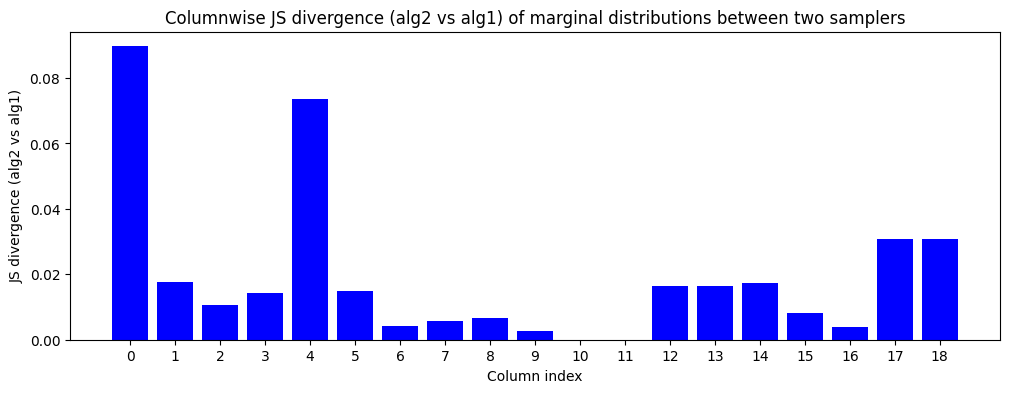

In [ ]:
plot_distr_distances(JS_divergences1_2, "JS divergence (alg2 vs alg1)")

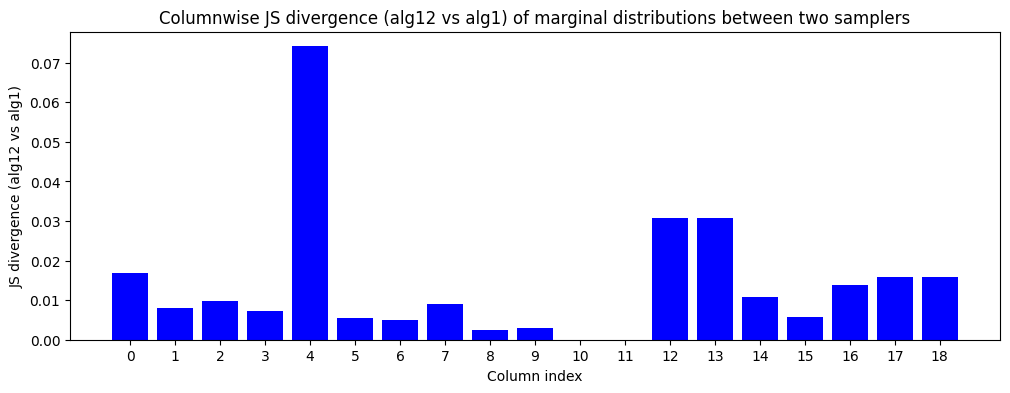

In [ ]:
plot_distr_distances(JS_divergences1_12, "JS divergence (alg12 vs alg1)")

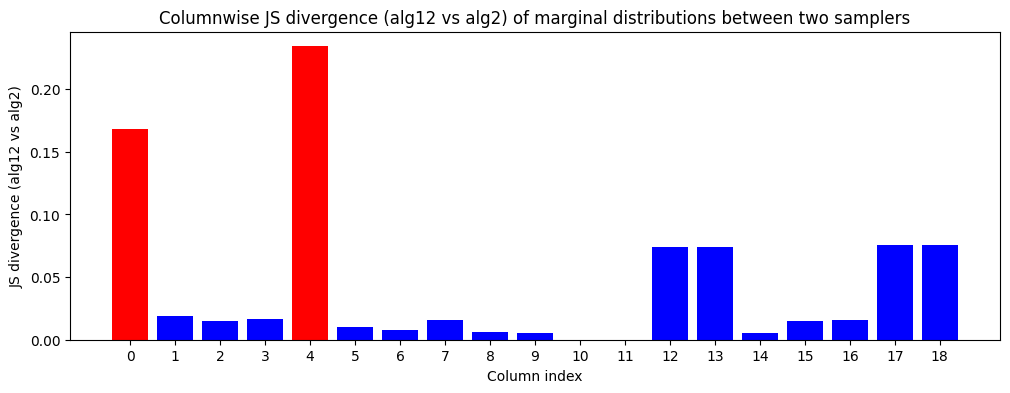

In [ ]:
plot_distr_distances(JS_divergences2_12, "JS divergence (alg12 vs alg2)")

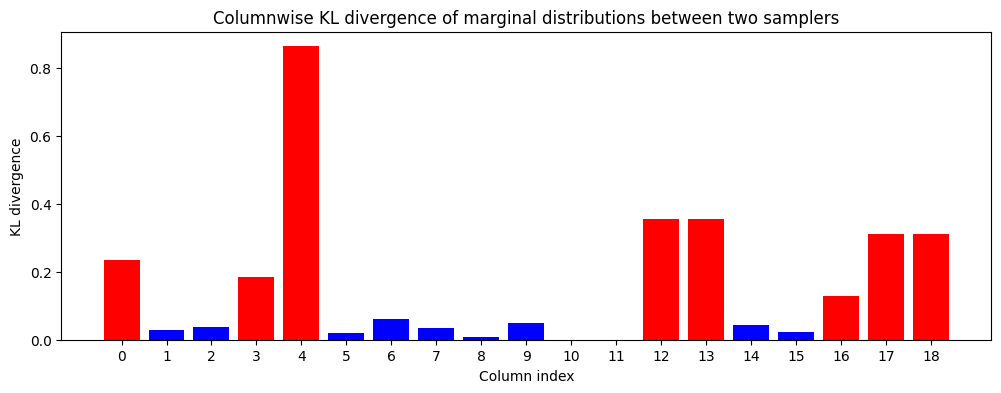

In [ ]:
plot_distr_distances(KL_divergences1_12, "KL divergence")

Since distsances between marginal distributions doesn't seem to show any significant difference between these distributions, we can assume both algorithms `alg2` and `alg12`  can be used to sample subsamples from the given dataset. However, more research may be required